## 1. Understanding the Data

In [86]:
import pandas as pd
import numpy as np

daily_path = "../data/raw/pharma_sales/salesdaily.csv"

df = pd.read_csv(daily_path)

df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [87]:
df.shape

(2106, 13)

In [88]:
df.columns.tolist()

['datum',
 'M01AB',
 'M01AE',
 'N02BA',
 'N02BE',
 'N05B',
 'N05C',
 'R03',
 'R06',
 'Year',
 'Month',
 'Hour',
 'Weekday Name']

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(2)
memory usage: 214.0 KB


In [90]:
df.describe(include="all")

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
count,2106,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106
unique,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
top,1/2/2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thursday
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,301
mean,NaN,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869,NaN
std,NaN,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000,NaN
25%,NaN,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000,NaN
50%,NaN,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000,NaN
75%,NaN,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000,NaN


In [91]:
df["datum"] = pd.to_datetime(df["datum"])

In [92]:
df["datum"].min(), df["datum"].max()

(Timestamp('2014-01-02 00:00:00'), Timestamp('2019-10-08 00:00:00'))

In [93]:
df.isnull().sum()

datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64

In [94]:
df.duplicated().sum()

np.int64(0)

In [95]:
df.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='str')

## 2. Data Cleaning & Reshaping

In [96]:
product_cols = [
    "M01AB",
    "M01AE",
    "N02BA",
    "N02BE",
    "N05B",
    "N05C",
    "R03",
    "R06"
]

In [97]:
df[product_cols].dtypes

M01AB    float64
M01AE    float64
N02BA    float64
N02BE    float64
N05B     float64
N05C     float64
R03      float64
R06      float64
dtype: object

In [98]:
sales_daily = df[["datum"] + product_cols].copy()

sales_daily["datum"] = pd.to_datetime(sales_daily["datum"])

sales_daily.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0


In [99]:
sales_long = sales_daily.melt(
    id_vars="datum",
    value_vars=product_cols,
    var_name="product_code",
    value_name="sales"
)

sales_long.head(10)

,datum,product_code,sales
0,2014-01-02,M01AB,0.00
1,2014-01-03,M01AB,8.00
2,2014-01-04,M01AB,2.00
3,2014-01-05,M01AB,4.00
4,2014-01-06,M01AB,5.00
5,2014-01-07,M01AB,0.00
6,2014-01-08,M01AB,5.33
7,2014-01-09,M01AB,7.00
8,2014-01-10,M01AB,5.00
9,2014-01-11,M01AB,5.00


In [100]:
sales_long.shape

(16848, 3)

In [101]:
sales_long["sales"].describe()

count    16848.000000
mean         7.573332
std         10.895998
min          0.000000
25%          1.817750
50%          4.000000
75%          8.000000
max        161.000000
Name: sales, dtype: float64

In [102]:
sales_long.groupby("product_code")["sales"].agg(
    ["count", "sum", "mean", "median", "std", "min", "max"]
).sort_values("sum", ascending=False)

,count,sum,mean,median,std,min,max
product_code,,,,,,,
N02BE,2106,63005.402708,29.917095,26.90,15.590966,0.0,161.000000
N05B,2106,18645.737500,8.853627,8.00,5.605605,0.0,54.833333
R03,2106,11608.822917,5.512262,4.00,6.428736,0.0,45.000000
M01AB,2106,10600.937083,5.033683,4.99,2.737579,0.0,17.340000
M01AE,2106,8204.618646,3.895830,3.67,2.133337,0.0,14.463000
N02BA,2106,8172.209000,3.880441,3.50,2.384010,0.0,16.000000
R06,2106,6107.817500,2.900198,2.00,2.415816,0.0,15.000000
N05C,2106,1249.958333,0.593522,0.00,1.092988,0.0,9.000000


In [103]:
product_summary = (
    sales_long
    .groupby("product_code")["sales"]
    .sum()
    .sort_values(ascending=False)
)

product_share = (
    product_summary / product_summary.sum() * 100
).round(2)

product_share

product_code
N02BE    49.38
N05B     14.61
R03       9.10
M01AB     8.31
M01AE     6.43
N02BA     6.40
R06       4.79
N05C      0.98
Name: sales, dtype: float64

In [104]:
monthly_product_sales = (
    sales_long
    .assign(month=sales_long["datum"].dt.to_period("M"))
    .groupby(["month", "product_code"])["sales"]
    .sum()
    .reset_index()
)

monthly_product_sales.head()

,month,product_code,sales
0,2014-01,M01AB,127.69
1,2014-01,M01AE,99.09
2,2014-01,N02BA,152.10
3,2014-01,N02BE,878.03
4,2014-01,N05B,354.00


In [105]:
monthly_product_sales = (
    sales_long
    .assign(
        month=sales_long["datum"].dt.to_period("M").dt.start_time
    )
    .groupby(["month", "product_code"])["sales"]
    .sum()
    .reset_index()
)

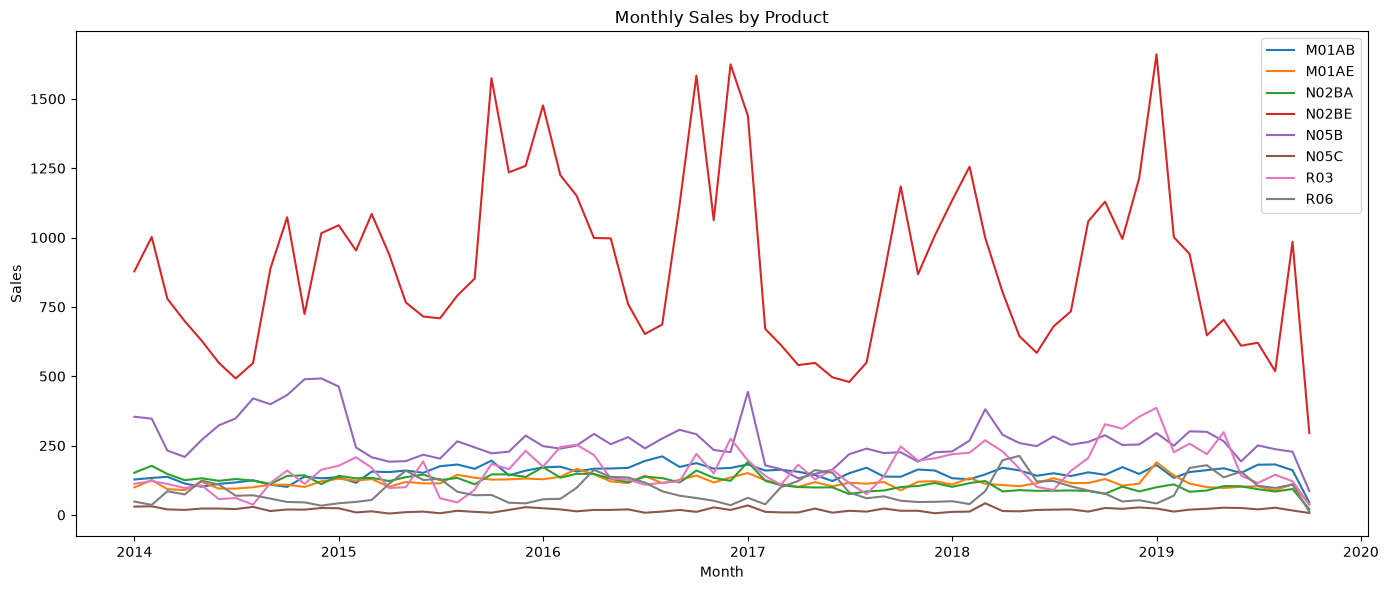

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for product in product_cols:
    product_data = monthly_product_sales[
        monthly_product_sales["product_code"] == product
    ]

    plt.plot(
        product_data["month"],
        product_data["sales"],
        label=product
    )

plt.title("Monthly Sales by Product")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Product Dimension

In [107]:
product_dim = pd.DataFrame({
    "product_code": [
        "M01AB",
        "M01AE",
        "N02BA",
        "N02BE",
        "N05B",
        "N05C",
        "R03",
        "R06"
    ],
    "product_category": [
        "Acetic acid derivatives and related substances",
        "Propionic acid derivatives",
        "Salicylic acid and derivatives",
        "Anilides",
        "Anxiolytics",
        "Hypnotics and sedatives",
        "Drugs for obstructive airway diseases",
        "Antihistamines for systemic use"
    ],
    "therapeutic_area": [
        "Musculoskeletal",
        "Musculoskeletal",
        "Analgesics",
        "Analgesics",
        "Nervous System",
        "Nervous System",
        "Respiratory",
        "Respiratory"
    ]
})

product_dim

,product_code,product_category,therapeutic_area
0,M01AB,Acetic acid derivatives and related substances,Musculoskeletal
1,M01AE,Propionic acid derivatives,Musculoskeletal
2,N02BA,Salicylic acid and derivatives,Analgesics
3,N02BE,Anilides,Analgesics
4,N05B,Anxiolytics,Nervous System
5,N05C,Hypnotics and sedatives,Nervous System
6,R03,Drugs for obstructive airway diseases,Respiratory
7,R06,Antihistamines for systemic use,Respiratory


In [108]:
product_dim.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   product_code      8 non-null      str  
 1   product_category  8 non-null      str  
 2   therapeutic_area  8 non-null      str  
dtypes: str(3)
memory usage: 324.0 bytes


In [109]:
product_dim["therapeutic_area"].value_counts()

therapeutic_area
Musculoskeletal    2
Analgesics         2
Nervous System     2
Respiratory        2
Name: count, dtype: int64

In [110]:
product_dim.to_csv(
    "../data/processed/dim_product.csv",
    index=False
)

In [111]:
pd.read_csv("../data/processed/dim_product.csv").head()

,product_code,product_category,therapeutic_area
0,M01AB,Acetic acid derivatives and related substances,Musculoskeletal
1,M01AE,Propionic acid derivatives,Musculoskeletal
2,N02BA,Salicylic acid and derivatives,Analgesics
3,N02BE,Anilides,Analgesics
4,N05B,Anxiolytics,Nervous System


## 4. Date Dimension

In [112]:
date_dim = pd.DataFrame({
    "date": pd.date_range(
        start=sales_long["datum"].min(),
        end=sales_long["datum"].max(),
        freq="D"
    )
})

date_dim["year"] = date_dim["date"].dt.year
date_dim["month"] = date_dim["date"].dt.month
date_dim["month_name"] = date_dim["date"].dt.month_name()
date_dim["quarter"] = date_dim["date"].dt.quarter
date_dim["week"] = date_dim["date"].dt.isocalendar().week
date_dim["day_of_week"] = date_dim["date"].dt.day_name()
date_dim["is_weekend"] = date_dim["date"].dt.dayofweek >= 5

In [113]:
date_dim.head()
date_dim.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2106 non-null   datetime64[us]
 1   year         2106 non-null   int32         
 2   month        2106 non-null   int32         
 3   month_name   2106 non-null   str           
 4   quarter      2106 non-null   int32         
 5   week         2106 non-null   UInt32        
 6   day_of_week  2106 non-null   str           
 7   is_weekend   2106 non-null   bool          
dtypes: UInt32(1), bool(1), datetime64[us](1), int32(3), str(2)
memory usage: 86.5 KB


In [114]:
date_dim.shape

(2106, 8)

In [115]:
date_dim["date"].min(), date_dim["date"].max()

(Timestamp('2014-01-02 00:00:00'), Timestamp('2019-10-08 00:00:00'))

In [116]:
date_dim.to_csv(
    "../data/processed/dim_date.csv",
    index=False
)

In [117]:
pd.read_csv("../data/processed/dim_date.csv").head()

,date,year,month,month_name,quarter,week,day_of_week,is_weekend
0,2014-01-02,2014,1,January,1,1,Thursday,False
1,2014-01-03,2014,1,January,1,1,Friday,False
2,2014-01-04,2014,1,January,1,1,Saturday,True
3,2014-01-05,2014,1,January,1,1,Sunday,True
4,2014-01-06,2014,1,January,1,2,Monday,False


## 5. Territory Dimension

In [118]:
territories = pd.DataFrame({
    "territory_id": [
        "T001", "T002", "T003", "T004", "T005",
        "T006", "T007", "T008", "T009", "T010",
        "T011", "T012", "T013", "T014", "T015",
        "T016", "T017", "T018", "T019", "T020"
    ],
    
    "territory_name": [
        "Delhi", "Jaipur", "Lucknow", "Chandigarh", "Patna",
        "Bengaluru", "Chennai", "Hyderabad", "Kochi", "Coimbatore",
        "Kolkata", "Bhubaneswar", "Visakhapatnam", "Guwahati", "Pune",
        "Mumbai", "Ahmedabad", "Surat", "Indore", "Nagpur"
    ],
    
    "region": [
        "North", "North", "North", "North", "North",
        "South", "South", "South", "South", "South",
        "East", "East", "East", "East",
        "West", "West", "West", "West", "West", "West"
    ]
})

territories

,territory_id,territory_name,region
0,T001,Delhi,North
1,T002,Jaipur,North
2,T003,Lucknow,North
3,T004,Chandigarh,North
4,T005,Patna,North
5,T006,Bengaluru,South
6,T007,Chennai,South
7,T008,Hyderabad,South
8,T009,Kochi,South
9,T010,Coimbatore,South


In [119]:
territories.shape

(20, 3)

In [120]:
territories["territory_id"].nunique(), territories["territory_name"].nunique()

(20, 20)

In [121]:
territories["region"].value_counts()

region
West     6
North    5
South    5
East     4
Name: count, dtype: int64

In [122]:
np.random.seed(42)

In [123]:
market_potential = np.random.normal(
    loc=70,
    scale=15,
    size=len(territories)
)

market_potential = np.clip(
    market_potential,
    30,
    100
).round(2)

market_potential

array([77.45, 67.93, 79.72, 92.85, 66.49, 66.49, 93.69, 81.51, 62.96,
       78.14, 63.05, 63.01, 73.63, 41.3 , 44.13, 61.57, 54.81, 74.71,
       56.38, 48.82])

In [124]:
territories["market_potential"] = market_potential

territories

,territory_id,territory_name,region,market_potential
0,T001,Delhi,North,77.45
1,T002,Jaipur,North,67.93
2,T003,Lucknow,North,79.72
3,T004,Chandigarh,North,92.85
4,T005,Patna,North,66.49
5,T006,Bengaluru,South,66.49
6,T007,Chennai,South,93.69
7,T008,Hyderabad,South,81.51
8,T009,Kochi,South,62.96
9,T010,Coimbatore,South,78.14


In [125]:
territories["market_potential"].describe()

count    20.000000
mean     67.432000
std      14.400332
min      41.300000
25%      60.272500
50%      66.490000
75%      77.622500
max      93.690000
Name: market_potential, dtype: float64

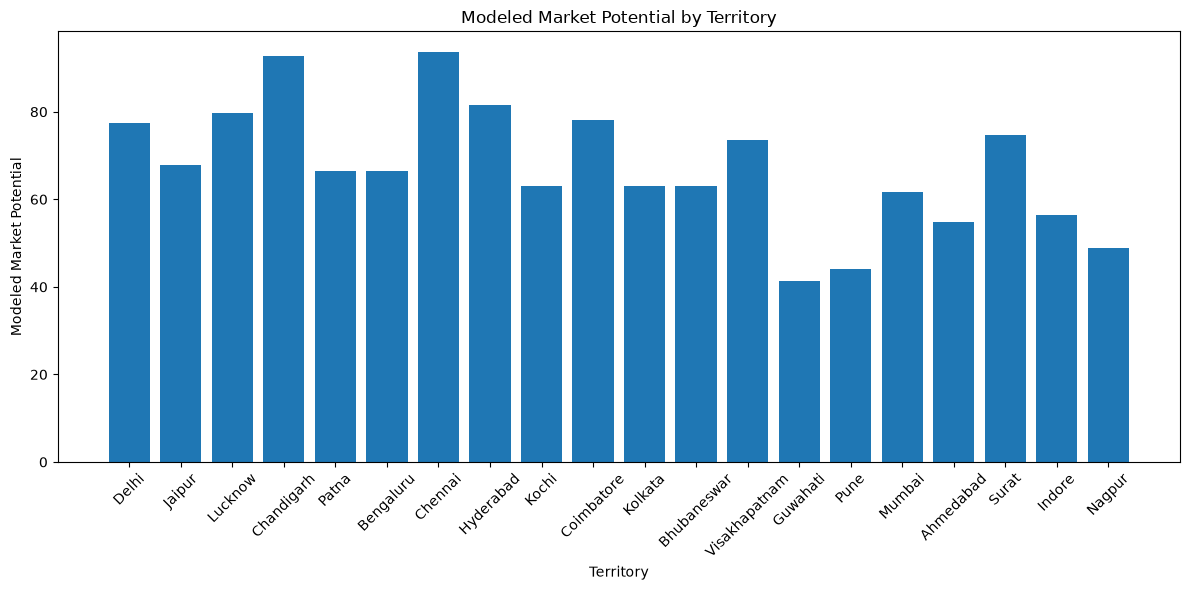

In [126]:
plt.figure(figsize=(12, 6))

plt.bar(
    territories["territory_name"],
    territories["market_potential"]
)

plt.title("Modeled Market Potential by Territory")
plt.xlabel("Territory")
plt.ylabel("Modeled Market Potential")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [127]:
territories.groupby("region")["market_potential"].agg(
    ["count", "mean", "min", "max"]
).round(2)

,count,mean,min,max
region,,,,
East,4,60.25,41.30,73.63
North,5,76.89,66.49,92.85
South,5,76.56,62.96,93.69
West,6,56.74,44.13,74.71


In [128]:
territories.sort_values(
    "market_potential",
    ascending=False
)

,territory_id,territory_name,region,market_potential
6,T007,Chennai,South,93.69
3,T004,Chandigarh,North,92.85
7,T008,Hyderabad,South,81.51
2,T003,Lucknow,North,79.72
9,T010,Coimbatore,South,78.14
0,T001,Delhi,North,77.45
17,T018,Surat,West,74.71
12,T013,Visakhapatnam,East,73.63
1,T002,Jaipur,North,67.93
4,T005,Patna,North,66.49


In [129]:
dim_territory = territories[
    [
        "territory_id",
        "territory_name",
        "region",
        "market_potential"
    ]
].copy()

dim_territory

,territory_id,territory_name,region,market_potential
0,T001,Delhi,North,77.45
1,T002,Jaipur,North,67.93
2,T003,Lucknow,North,79.72
3,T004,Chandigarh,North,92.85
4,T005,Patna,North,66.49
5,T006,Bengaluru,South,66.49
6,T007,Chennai,South,93.69
7,T008,Hyderabad,South,81.51
8,T009,Kochi,South,62.96
9,T010,Coimbatore,South,78.14


In [130]:
print("Shape:", dim_territory.shape)
print("Unique territories:", dim_territory["territory_id"].nunique())
print("Unique names:", dim_territory["territory_name"].nunique())
print("Missing values:", dim_territory.isnull().sum().sum())
print("Duplicate rows:", dim_territory.duplicated().sum())

Shape: (20, 4)
Unique territories: 20
Unique names: 20
Missing values: 0
Duplicate rows: 0


### Territory Modeling Note

The territory dimension is synthetic/modelled data created for this project.

Territory names are used as realistic market-style labels, but they do not represent an actual pharmaceutical company's sales territory structure.

`market_potential` is a modeled relative opportunity score generated using a fixed random seed and controlled variation. It should not be interpreted as actual geographic market size, population, pharmaceutical demand, or revenue.

The territory layer will later be combined with observed product demand and additional modeled commercial variables to construct the territory sales and opportunity analysis.

In [131]:
dim_territory.to_csv(
    "../data/processed/dim_territory.csv",
    index=False
)

In [132]:
pd.read_csv("../data/processed/dim_territory.csv").head()

,territory_id,territory_name,region,market_potential
0,T001,Delhi,North,77.45
1,T002,Jaipur,North,67.93
2,T003,Lucknow,North,79.72
3,T004,Chandigarh,North,92.85
4,T005,Patna,North,66.49


## 6. HCP Dimension

We create approximately 500 synthetic healthcare professionals (HCPs) distributed across the modeled territories.

Each HCP is assigned a specialty, commercial tier, and potential score. The HCP model is synthetic and is used to support sales-force coverage and opportunity analysis.

In [133]:
num_hcps = 500

In [134]:
# assigning territories to HCPs based on market potential

territory_weights = dim_territory["market_potential"].values
territory_weights = territory_weights / territory_weights.sum()

hcp_territories = np.random.choice(
    dim_territory["territory_id"],
    size=num_hcps,
    p=territory_weights
)

In [135]:
hcp_ids = [
    f"H{i:03d}" for i in range(1, num_hcps + 1)
]

In [136]:
specialty_by_area = {
    "Musculoskeletal": [
        "Orthopedist",
        "Rheumatologist"
    ],
    "Analgesics": [
        "General Physician",
        "Pain Specialist"
    ],
    "Nervous System": [
        "Psychiatrist",
        "Neurologist"
    ],
    "Respiratory": [
        "Pulmonologist",
        "Allergist"
    ]
}

In [137]:
specialties = [
    specialty
    for specialty_list in specialty_by_area.values()
    for specialty in specialty_list
]

specialties

['Orthopedist',
 'Rheumatologist',
 'General Physician',
 'Pain Specialist',
 'Psychiatrist',
 'Neurologist',
 'Pulmonologist',
 'Allergist']

In [138]:
hcp_specialties = np.random.choice(
    specialties,
    size=num_hcps,
    p=[
        0.12,  # Orthopedist
        0.08,  # Rheumatologist
        0.25,  # General Physician
        0.08,  # Pain Specialist
        0.12,  # Psychiatrist
        0.08,  # Neurologist
        0.15,  # Pulmonologist
        0.12   # Allergist
    ]
)

In [139]:
hcp_tiers = np.random.choice(
    ["A", "B", "C"],
    size=num_hcps,
    p=[0.20, 0.35, 0.45]
)

In [140]:
potential_score = np.random.normal(
    loc=60,
    scale=18,
    size=num_hcps
)

potential_score = np.clip(
    potential_score,
    10,
    100
)

In [141]:
tier_adjustment = {
    "A": 20,
    "B": 5,
    "C": -10
}

potential_score = (
    potential_score
    + pd.Series(hcp_tiers).map(tier_adjustment).values
)

potential_score = np.clip(
    potential_score,
    10,
    100
).round(2)

In [142]:
dim_hcp = pd.DataFrame({
    "hcp_id": hcp_ids,
    "territory_id": hcp_territories,
    "specialty": hcp_specialties,
    "hcp_tier": hcp_tiers,
    "potential_score": potential_score
})

dim_hcp.head()

,hcp_id,territory_id,specialty,hcp_tier,potential_score
0,H001,T008,Pulmonologist,C,19.53
1,H002,T016,Pain Specialist,B,63.23
2,H003,T004,General Physician,C,32.21
3,H004,T010,General Physician,C,30.14
4,H005,T011,Orthopedist,B,68.24


In [143]:
dim_hcp.to_csv(
    "../data/processed/dim_hcp.csv",
    index=False
)

In [144]:
dim_hcp.groupby("hcp_tier")["potential_score"].agg(
    ["count", "mean", "min", "max"]
).round(2)

,count,mean,min,max
hcp_tier,,,,
A,100,78.45,30.00,100.0
B,161,66.42,18.36,100.0
C,239,50.99,10.00,90.0


In [145]:
dim_hcp["territory_id"].value_counts().describe()

count    20.0000
mean     25.0000
std       6.6491
min      12.0000
25%      20.0000
50%      25.5000
75%      31.2500
max      35.0000
Name: count, dtype: float64

## 7. Sales Representative Dimension & Activity

Creating a synthetic sales force with one representative assigned to each modeled territory.

Representatives are responsible for engaging HCPs within their assigned territory. Their activity will later be used to evaluate sales-force coverage and productivity.

In [146]:
num_reps = len(dim_territory)

rep_ids = [
    f"R{i:03d}" for i in range(1, num_reps + 1)
]

In [147]:
rep_names = [
    "Aarav Sharma",
    "Priya Mehta",
    "Rohan Desai",
    "Ananya Iyer",
    "Vikram Shah",
    "Neha Kapoor",
    "Arjun Nair",
    "Sneha Rao",
    "Karan Malhotra",
    "Riya Menon",
    "Aditya Sen",
    "Kavya Joshi",
    "Rahul Verma",
    "Ishita Patel",
    "Siddharth Kulkarni",
    "Meera Krishnan",
    "Varun Agarwal",
    "Nisha Bansal",
    "Akash Gupta",
    "Tanya Roy"
]

In [148]:
dim_rep = pd.DataFrame({
    "rep_id": rep_ids,
    "rep_name": rep_names,
    "territory_id": dim_territory["territory_id"].values
})

dim_rep

,rep_id,rep_name,territory_id
0,R001,Aarav Sharma,T001
1,R002,Priya Mehta,T002
2,R003,Rohan Desai,T003
3,R004,Ananya Iyer,T004
4,R005,Vikram Shah,T005
5,R006,Neha Kapoor,T006
6,R007,Arjun Nair,T007
7,R008,Sneha Rao,T008
8,R009,Karan Malhotra,T009
9,R010,Riya Menon,T010


In [149]:
dim_rep.to_csv(
    "../data/processed/dim_rep.csv",
    index=False
)

In [150]:
call_dates = date_dim["date"]

In [151]:
num_calls = 40000

In [152]:
call_date = np.random.choice(
    call_dates,
    size=num_calls
)

In [153]:
# Select reps for calls
call_rep_ids = np.random.choice(
    dim_rep["rep_id"],
    size=num_calls
)

call_territories = (
    dim_rep
    .set_index("rep_id")
    .loc[call_rep_ids, "territory_id"]
    .values
)

In [154]:
# Determine which HCPs are eligible to receive calls
hcp_base = dim_hcp.copy()

hcp_base["coverage_probability"] = hcp_base["hcp_tier"].map({
    "A": 0.95,
    "B": 0.85,
    "C": 0.75
})

np.random.seed(42)

hcp_base["eligible"] = (
    np.random.random(len(hcp_base))
    < hcp_base["coverage_probability"]
)

eligible_hcps = hcp_base[
    hcp_base["eligible"]
].copy()

# Weight call assignment toward higher-potential HCPs
eligible_hcps["call_weight"] = (
    eligible_hcps["potential_score"]
    * eligible_hcps["hcp_tier"].map({
        "A": 1.5,
        "B": 1.0,
        "C": 0.7
    })
)

# HCPs grouped by territory
hcp_by_territory = {
    territory_id: group
    for territory_id, group
    in eligible_hcps.groupby("territory_id")
}

In [155]:
# Select HCPs from the rep's territory
call_hcps = []

for territory in call_territories:

    territory_hcps = hcp_by_territory[territory]

    weights = (
        territory_hcps["call_weight"]
        / territory_hcps["call_weight"].sum()
    )

    selected_hcp = np.random.choice(
        territory_hcps["hcp_id"].values,
        p=weights.values
    )

    call_hcps.append(selected_hcp)

In [156]:
call_outcomes = np.random.choice(
    [
        "Successful",
        "Follow-up Required",
        "No Contact"
    ],
    size=num_calls,
    p=[0.55, 0.30, 0.15]
)

In [157]:
fact_calls = pd.DataFrame({
    "date": call_date,
    "rep_id": call_rep_ids,
    "territory_id": call_territories,
    "hcp_id": call_hcps,
    "call_outcome": call_outcomes
})

fact_calls.head()

,date,rep_id,territory_id,hcp_id,call_outcome
0,2016-06-15,R003,T003,H357,No Contact
1,2018-08-03,R004,T004,H211,Successful
2,2016-07-20,R009,T009,H208,Successful
3,2014-10-17,R016,T016,H398,Successful
4,2015-12-26,R019,T019,H388,Follow-up Required


In [158]:
fact_calls.to_csv(
    "../data/processed/fact_calls.csv",
    index=False
)

## 8. Sales Model

In [159]:
territory_weights = dim_territory[
    ["territory_id", "market_potential"]
].copy()

territory_weights["allocation_weight"] = (
    territory_weights["market_potential"]
    / territory_weights["market_potential"].sum()
)

territory_weights

,territory_id,market_potential,allocation_weight
0,T001,77.45,0.057428
1,T002,67.93,0.050369
2,T003,79.72,0.059111
3,T004,92.85,0.068847
4,T005,66.49,0.049302
5,T006,66.49,0.049302
6,T007,93.69,0.069470
7,T008,81.51,0.060439
8,T009,62.96,0.046684
9,T010,78.14,0.057940


In [160]:
territory_sales = sales_long.copy()

territory_sales = territory_sales.rename(
    columns={"datum": "date"}
)

In [161]:
territories_for_join = territory_weights[
    ["territory_id", "market_potential", "allocation_weight"]
]

In [162]:
territory_sales = sales_long.copy()

territory_sales = territory_sales.rename(
    columns={"datum": "date"}
)

territory_sales = territory_sales.merge(
    territories_for_join,
    how="cross"
)

In [163]:
territory_sales["baseline_sales"] = (
    territory_sales["sales"]
    * territory_sales["allocation_weight"]
)

In [164]:
np.random.seed(42)

variation = np.random.normal(
    loc=1.0,
    scale=0.10,
    size=len(territory_sales)
)

variation = np.clip(
    variation,
    0.75,
    1.25
)

In [165]:
territory_sales["territory_sales"] = (
    territory_sales["baseline_sales"]
    * variation
)

In [166]:
territory_sales["territory_sales"] = (
    territory_sales["territory_sales"]
    .round(2)
)

In [167]:
fact_territory_sales = territory_sales[
    [
        "date",
        "territory_id",
        "product_code",
        "territory_sales"
    ]
].copy()

In [168]:
fact_territory_sales = fact_territory_sales.rename(
    columns={"territory_sales": "sales"}
)

In [169]:
fact_territory_sales.to_csv(
    "../data/processed/fact_territory_sales.csv",
    index=False
)

In [170]:
territory_totals = (
    fact_territory_sales
    .groupby("product_code")["sales"]
    .sum()
)

observed_totals = (
    sales_long
    .groupby("product_code")["sales"]
    .sum()
)

comparison = pd.DataFrame({
    "observed": observed_totals,
    "modeled": territory_totals
})

comparison["difference_pct"] = (
    (comparison["modeled"] - comparison["observed"])
    / comparison["observed"]
    * 100
)

comparison.round(2)

,observed,modeled,difference_pct
product_code,,,
M01AB,10600.94,10603.44,0.02
M01AE,8204.62,8205.30,0.01
N02BA,8172.21,8173.27,0.01
N02BE,63005.40,63035.23,0.05
N05B,18645.74,18633.95,-0.06
N05C,1249.96,1248.49,-0.12
R03,11608.82,11609.39,0.00
R06,6107.82,6105.96,-0.03
